In [1]:
!uv pip install torch torchvision datasets pillow matplotlib tqdm

Checked 6 packages in 96ms


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import numpy as np
from PIL import Image

In [3]:
import ssl
import urllib.request

# Disable SSL verification globally
ssl._create_default_https_context = ssl._create_unverified_context

In [4]:
class DoubleConv(nn.Module):
    """(Convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False, dtype=torch.float16),
            nn.BatchNorm2d(out_channels, dtype=torch.float16),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False, dtype=torch.float16),
            nn.BatchNorm2d(out_channels, dtype=torch.float16),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3): # Changed to 3 classes for Oxford Pets
        super().__init__()
        # Encoder (Downsampling)
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        
        # Decoder (Upsampling)
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2, dtype=torch.float16)
        self.conv1 = DoubleConv(512, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2, dtype=torch.float16)
        self.conv2 = DoubleConv(256, 128)
        
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2, dtype=torch.float16)
        self.conv3 = DoubleConv(128, 64)
        
        # Final Output Map
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1, dtype=torch.float16)

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        
        # Decoder with Skip Connections
        x = self.up1(x4)
        x = torch.cat([x, x3], dim=1) 
        x = self.conv1(x)
        
        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)
        
        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv3(x)
        
        return self.outc(x)

In [66]:
model

UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Sequential(
    (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1): DoubleConv(
      (double_conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        

In [5]:
# 2. DATASET LOADING AND PREPROCESSING VIA TORCHVISION
print("Downloading and loading Oxford-IIIT Pet dataset from Torchvision...")

IMG_SIZE = (256, 256)

# Transforms for images (Normalize & Resize)
img_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transforms for segmentation masks
# PILToTensor preserves the raw integer values (1, 2, 3) instead of scaling to 0.0 - 1.0
mask_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor() 
])

def custom_target_transform(mask):
    mask = mask_transform(mask)
    mask = mask.to(torch.int64) # Convert to long integer for CrossEntropyLoss
    mask = mask.squeeze(0)      # Remove channel dim: [1, 256, 256] -> [256, 256]
    return mask - 1             # Shift labels from {1, 2, 3} to {0, 1, 2}

# Download and load the dataset
train_dataset = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=img_transform,
    target_transform=custom_target_transform
)

# A simple Dataloader without a custom collate_fn is fine here
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [6]:
# 3. TRAINING SETUP
device = torch.device("cuda" if torch.cuda.is_available() else "mps")

# Initialize U-Net with 3 output channels
model = UNet(in_channels=3, out_channels=3).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=255) 
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

print(f"Starting training on device: {device}...")

Starting training on device: mps...


In [7]:
import tqdm

# 4. MINI TRAINING LOOP
epochs = 3
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    
    # We will just run a few batches for demonstration if the dataset is large
    for i, (images, masks) in tqdm.tqdm(enumerate(train_loader), ncols=80, total=len(train_loader)):
        images, masks = images.to(device), masks.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
            
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss/(i+1):.4f}")

print("Training finished successfully!")

100%|█████████████████████████████████████████| 230/230 [09:17<00:00,  2.42s/it]


Epoch [1/3] - Loss: 0.6925


100%|█████████████████████████████████████████| 230/230 [09:09<00:00,  2.39s/it]


Epoch [2/3] - Loss: 0.5815


100%|█████████████████████████████████████████| 230/230 [09:11<00:00,  2.40s/it]

Epoch [3/3] - Loss: 0.5179
Training finished successfully!


Loading test dataset for evaluation...
Evaluating on random test image index: 832


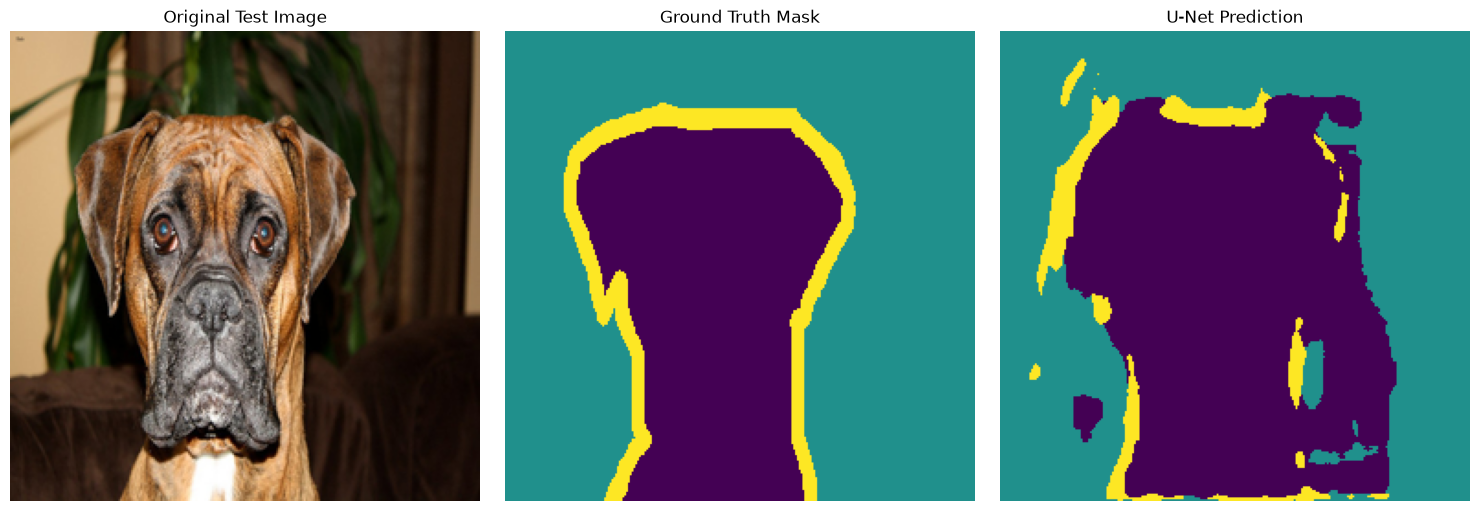

In [13]:
import random
import matplotlib.pyplot as plt

# 1. LOAD THE TEST/VALIDATION DATASET
print("Loading test dataset for evaluation...")

# Load raw dataset without transforms first so we can display the original image easily
test_dataset_raw = torchvision.datasets.OxfordIIITPet(
    root="./data",
    split="test", 
    target_types="segmentation",
    download=True
)

# 2. PICK A RANDOM SAMPLE
random_idx = random.randint(0, len(test_dataset_raw) - 1)
raw_image, raw_mask = test_dataset_raw[random_idx]
print(f"Evaluating on random test image index: {random_idx}")

# 3. PREPROCESS AND RUN INFERENCE
model.eval() # Switch model to evaluation mode (fixes BatchNorm behaviors)

# Apply your existing image transformation pipeline and add the batch dimension
# [C, H, W] -> [1, C, H, W]
input_tensor = img_transform(raw_image).unsqueeze(0).to(device)

with torch.no_grad(): # Disable gradients to save memory and processing power
    output = model(input_tensor)
    
    # Take argmax along the class channel dimension (dim=1) to find the top predicted label per pixel
    predicted_mask = torch.argmax(output, dim=1)
    
    # Bring back to CPU and remove the batch dimension for plotting: [1, 256, 256] -> [256, 256]
    predicted_mask = predicted_mask.squeeze(0).cpu().numpy()

# 4. PLOT RESULTS SIDE-BY-SIDE
plt.figure(figsize=(15, 5))

# Plot 1: Input Image
plt.subplot(1, 3, 1)
plt.title("Original Test Image")
plt.imshow(raw_image.resize(IMG_SIZE))
plt.axis("off")

# Plot 2: Ground Truth
plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
# Nearest neighbor interpolation keeps the clean pixel class boundaries intact
plt.imshow(raw_mask.resize(IMG_SIZE, resample=Image.NEAREST), cmap="viridis")
plt.axis("off")

# Plot 3: Model's Prediction
plt.subplot(1, 3, 3)
plt.title("U-Net Prediction")
plt.imshow(predicted_mask, cmap="viridis")
plt.axis("off")

plt.tight_layout()
plt.show()